# Laboratorio 2: Deep Learning aplicado a series de tiempo
## Ejercicio 2: Similitud de series con catch22

Link repo: https://github.com/nilsmuralles/Lab2-DataScience.git

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pycatch22
import tensorflow as tf
from tensorflow import keras

DATA_PATH = "Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx"

# Mismo estilo visual que en las libretas del Laboratorio 1 y las de LSTM
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "grid.color": "#e1e0d9",
    "axes.grid": True,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "figure.dpi": 100,
})

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

SEED = 42
np.random.seed(SEED)

## 1. Reconstrucción de las 6 series del Laboratorio 1

In [3]:
df = pd.read_excel(DATA_PATH, sheet_name="Datos")
df["fecha"] = pd.to_datetime(dict(year=df["Año"], month=df["Mes cod"], day=1))

fecha_ini, fecha_fin = df["fecha"].min(), df["fecha"].max()
rango_completo = pd.date_range(fecha_ini, fecha_fin, freq="MS")

print(f"Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Rango completo: {fecha_ini.strftime('%Y-%m')} a {fecha_fin.strftime('%Y-%m')} ({len(rango_completo)} meses)")

Dimensiones del dataset: 161,036 filas x 14 columnas
Rango completo: 2009-01 a 2026-06 (210 meses)


In [4]:
def construir_serie(data, columna, valor):
    s = data[data[columna] == valor].groupby("fecha")["Viajero"].sum()
    s = s.reindex(rango_completo, fill_value=0.0)
    s.index.name = "fecha"
    return s


# Países de residencia: mismo filtro que serie_paises_residencia.ipynb (Turista + Excursionista,
# consistente en todo el período; excluye Guatemala por el quiebre estructural post-2022)
df_paises = df[df["Tipo de Viajero"].isin(["Turista", "Excursionista"])]
paises_top3 = ["El Salvador", "Estados Unidos de América", "Honduras"]

# Regiones geográficas: mismo criterio que series_regiones_geograficas.ipynb (Región dos,
# sin filtrar por tipo de viajero)
regiones_top3 = ["América Del Centro", "América Del Norte", "Europa"]

series_dict = {}
for pais in paises_top3:
    series_dict[pais] = construir_serie(df_paises, "País", pais)
for region in regiones_top3:
    series_dict[region] = construir_serie(df, "Región dos", region)

resumen = pd.DataFrame({
    nombre: {"Media": s.mean(), "Desv. estándar": s.std(), "Máximo": s.max(), "Meses en cero": (s == 0).sum()}
    for nombre, s in series_dict.items()
}).T.round(1)
resumen

,Media,Desv. estándar,Máximo,Meses en cero
El Salvador,67043.5,39195.5,190579.0,5.0
Estados Unidos de América,33169.9,15355.4,78927.2,5.0
Honduras,12004.6,8074.1,35252.5,5.0
América Del Centro,178126.4,80505.8,421838.0,0.0
América Del Norte,44681.1,18233.4,99416.0,5.0
Europa,10583.9,4604.6,23384.0,5.0


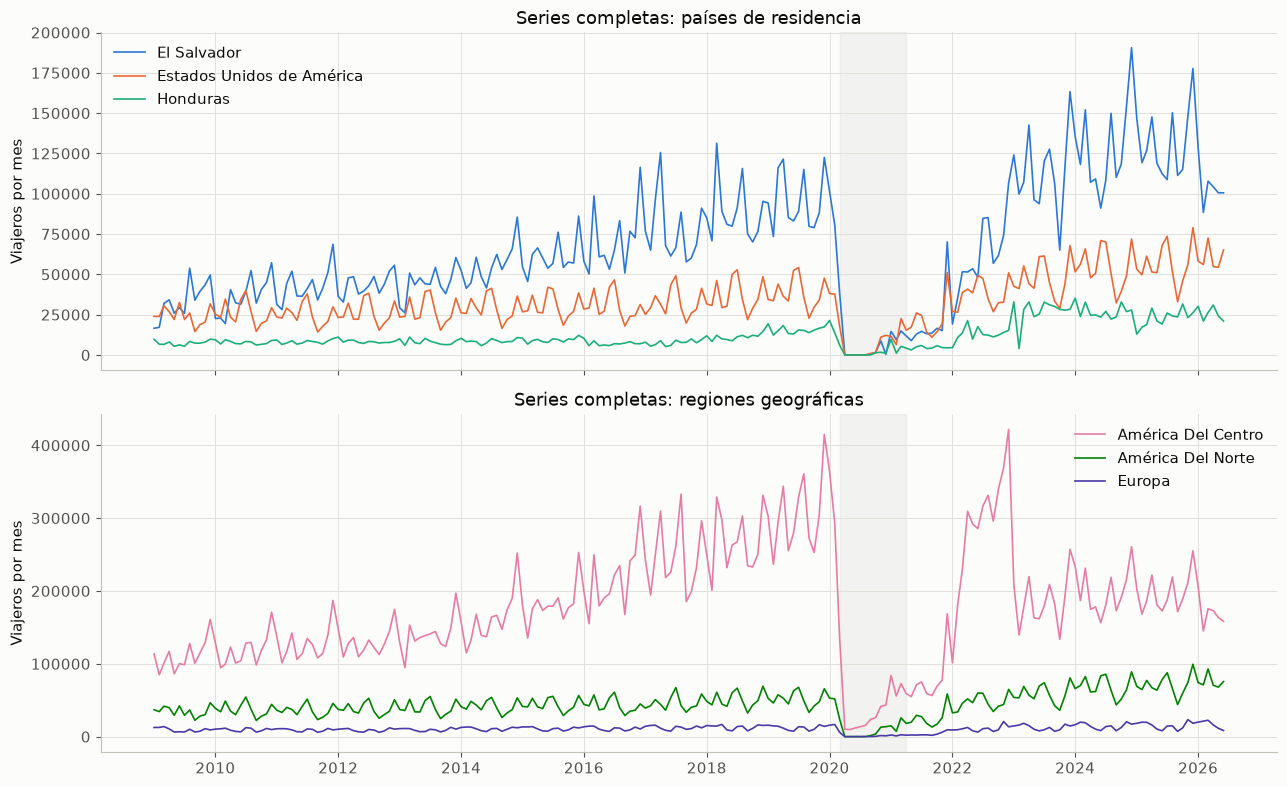

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

for i, pais in enumerate(paises_top3):
    axes[0].plot(series_dict[pais].index, series_dict[pais].values, color=PALETTE[i], linewidth=1.2, label=pais)
axes[0].set_title("Series completas: países de residencia")
axes[0].legend(frameon=False)

for i, region in enumerate(regiones_top3):
    axes[1].plot(series_dict[region].index, series_dict[region].values, color=PALETTE[i + 4], linewidth=1.2, label=region)
axes[1].set_title("Series completas: regiones geográficas")
axes[1].legend(frameon=False)

for ax in axes:
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-03-31"), color="gray", alpha=0.08)
    ax.set_ylabel("Viajeros por mes")

plt.tight_layout()
plt.show()

## 2. Ejercicio 2: catch22

### 2.1 ¿Qué es catch22 y por qué importa?

catch22 (CAnonical Time-series CHaracteristics, Fulcher, Little y Jones, 2013/2019) nace del proyecto *hctsa* (*highly comparative time-series analysis*), una librería que calcula más de 7,000 características distintas para cualquier serie de tiempo: valores como autocorrelación, entropía, fluctuaciones, distribución de valores, no linealidad, etc.

El problema con esas más de 7,000 características es que son muy redundantes entre sí (varias miden esencialmente lo mismo) y computacionalmente pesadas de calcular todas. Los autores de catch22 corrieron esas 7,000+ características sobre miles de series de datasets muy variados (finanzas, medicina, clima, procesos industriales) y se quedaron únicamente con un subconjunto de **22 características** que, en conjunto:

- Son poco redundantes entre sí (cada una captura algo que las otras 21 no captan).
- Conservan casi todo el poder de clasificación/discriminación de las más de 7,000 originales.
- Son rápidas de calcular, a diferencia del set completo de hctsa.
- Sirven para cualquier dominio, porque no se diseñaron pensando en un tipo de serie específico.

Es decir, catch22 es una forma de resumir una serie de tiempo completa (sin importar su longitud) en solo 22 números, de manera que dos series con "forma" parecida (tendencia, estacionalidad, memoria, volatilidad, etc.) queden con vectores de características parecidos, y se puedan comparar, agrupar o graficar sin tener que alinear las series en el tiempo. Es justo lo que se necesita para este ejercicio: comparar 6 series con escalas y períodos de mayor actividad distintos, a partir de su forma y no de sus valores absolutos.

### 2.2 Extracción de las 22 características por serie

In [6]:
catch22_resultados = {}
for nombre, serie in series_dict.items():
    res = pycatch22.catch22_all(serie.values.tolist())
    catch22_resultados[nombre] = dict(zip(res["names"], res["values"]))

nombres_features = list(next(iter(catch22_resultados.values())).keys())
print(f"{len(catch22_resultados)} series, {len(nombres_features)} características por serie")
pd.DataFrame(catch22_resultados[paises_top3[0]], index=[paises_top3[0]])

6 series, 22 características por serie


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
El Salvador,-0.25181,-0.494924,13.998392,2,0.345884,-0.009693,0.889952,31.0,0.020833,3,0.377974,1.0,0.038462,0.766667,0.309524,0.847661,5.0,1.803352,0.142857,0.857143,0.073631,0.537345


### 2.3 Matriz de características (series x catch22)

In [7]:
matriz_catch22 = pd.DataFrame(catch22_resultados).T
matriz_catch22 = matriz_catch22[nombres_features]  # conserva el orden original de catch22
matriz_catch22.index.name = "Serie"
matriz_catch22

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Serie,,,,,,,,,,,,,,,,,,,,,,
El Salvador,-0.251810,-0.494924,13.998392,2.0,0.345884,-0.009693,0.889952,31.0,0.020833,3.0,0.377974,1.0,0.038462,0.766667,0.309524,0.847661,5.0,1.803352,0.142857,0.857143,0.073631,0.537345
Estados Unidos de América,-0.618139,-0.361137,9.264622,2.0,0.256037,0.019514,0.909091,12.0,0.020833,5.0,0.265592,1.0,0.038462,0.828571,0.323810,0.724049,5.0,1.981011,0.166667,0.738095,0.098175,0.736974
Honduras,-0.176971,-0.395275,18.242108,8.0,0.452511,-0.093463,0.870813,39.0,0.055556,8.0,0.166816,7.0,0.029412,0.752381,0.319048,0.865881,5.0,1.796815,0.857143,0.738095,0.049087,0.474189
América Del Centro,-0.555608,-0.555608,8.348638,10.0,0.456909,-0.139984,0.909091,42.0,0.005510,11.0,0.243626,9.0,0.055556,0.219048,0.319048,0.831118,6.0,1.788784,0.761905,0.857143,0.147262,0.624887
América Del Norte,0.275697,-0.542167,9.134473,2.0,0.253041,-0.016483,0.952153,12.0,0.037037,3.0,0.287110,1.0,0.045455,0.828571,0.323810,0.740595,5.0,2.010477,0.166667,0.738095,0.098175,0.721577
Europa,0.240650,-0.013271,4.522684,2.0,0.336800,0.058315,0.918660,8.0,0.013889,7.0,0.226234,1.0,0.058824,0.738095,0.333333,0.766695,6.0,2.044771,0.142857,0.738095,0.171806,0.773784


### 2.4 Estandarización de las características

Antes de comparar, cada columna (característica) se estandariza a media 0 y desviación estándar 1. Es necesario porque las 22 características de catch22 no están en la misma escala entre sí (unas son proporciones entre 0 y 1, otras son conteos, otras son estadísticos de autocorrelación), así que sin estandarizar, las características con rangos más grandes dominarían cualquier distancia, PCA o clustering que se calcule después.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler_catch22 = StandardScaler()
matriz_catch22_std = pd.DataFrame(
    scaler_catch22.fit_transform(matriz_catch22),
    index=matriz_catch22.index,
    columns=matriz_catch22.columns,
)
matriz_catch22_std.round(2)

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Serie,,,,,,,,,,,,,,,,,,,,,,
El Salvador,-0.20,-0.55,0.78,-0.70,-0.05,0.31,-0.73,0.51,-0.29,-1.11,1.82,-0.70,-0.58,0.37,-1.67,0.95,-0.71,-0.92,-0.74,1.41,-0.78,-0.98
Estados Unidos de América,-1.26,0.18,-0.30,-0.70,-1.15,0.74,0.03,-0.87,-0.29,-0.41,0.07,-0.70,-0.58,0.66,0.33,-1.32,-0.71,0.70,-0.67,-0.71,-0.20,0.84
Honduras,0.01,-0.01,1.74,1.09,1.25,-0.94,-1.49,1.09,1.83,0.64,-1.47,1.09,-1.46,0.30,-0.33,1.28,-0.71,-0.98,1.56,-0.71,-1.37,-1.56
América Del Centro,-1.08,-0.88,-0.51,1.69,1.30,-1.64,0.03,1.30,-1.23,1.69,-0.27,1.69,1.09,-2.21,-0.33,0.64,1.41,-1.05,1.25,1.41,0.98,-0.18
América Del Norte,1.32,-0.80,-0.33,-0.70,-1.18,0.21,1.75,-0.87,0.70,-1.11,0.40,-0.70,0.11,0.66,0.33,-1.01,-0.71,0.97,-0.67,-0.71,-0.20,0.70
Europa,1.21,2.06,-1.38,-0.70,-0.16,1.32,0.41,-1.16,-0.71,0.29,-0.54,-0.70,1.41,0.23,1.67,-0.54,1.41,1.28,-0.74,-0.71,1.57,1.18


In [9]:
# Se guardan ambas matrices en csv, para que el resto del análisis (2.5 en adelante)
# se pueda retomar sin tener que volver a correr pycatch22.
matriz_catch22.to_csv("catch22_features_raw.csv")
matriz_catch22_std.to_csv("catch22_features_estandarizadas.csv")
print("Guardado: catch22_features_raw.csv y catch22_features_estandarizadas.csv")

Guardado: catch22_features_raw.csv y catch22_features_estandarizadas.csv


### 2.5 PCA, clustering, heatmap, correlación y distancias

A partir de `matriz_catch22_std` (la matriz ya estandarizada de la sección 2.4) se realizan los cinco análisis pedidos: PCA, clustering, heatmap de características, matriz de correlación entre características y mapa de distancias entre series.

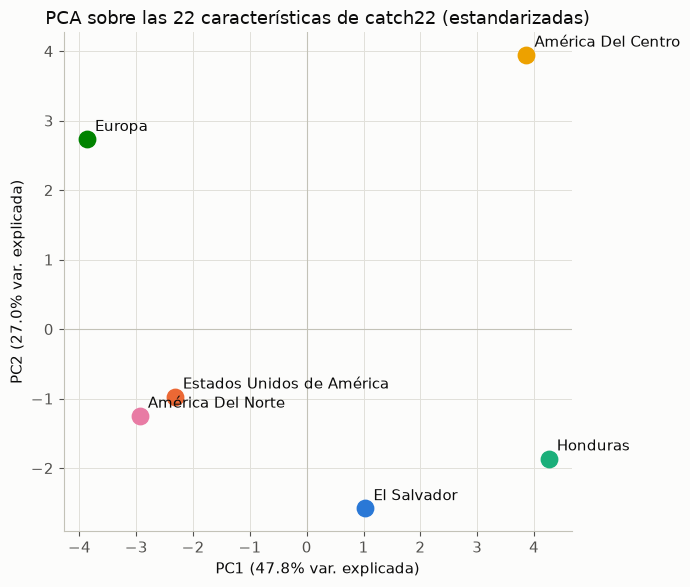

Varianza explicada acumulada (PC1+PC2): 74.9%

Características con mayor peso en PC1:
SB_BinaryStats_mean_longstretch1               0.305037
SB_MotifThree_quantile_hh                      0.295282
CO_trev_1_num                                  0.276590
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1    0.270937
CO_HistogramAMI_even_2_5                       0.270298
Name: PC1, dtype: float64

Características con mayor peso en PC2:
SB_BinaryStats_diff_longstretch0    0.396852
SP_Summaries_welch_rect_centroid    0.369299
FC_LocalSimple_mean1_tauresrat      0.359120
DN_OutlierInclude_p_001_mdrmd       0.309041
PD_PeriodicityWang_th0_01           0.306430
Name: PC2, dtype: float64


In [10]:
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
import seaborn as sns

# PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(matriz_catch22_std.values)
pcdf = pd.DataFrame(pcs, index=matriz_catch22_std.index, columns=["PC1", "PC2"])

fig, ax = plt.subplots(figsize=(7, 6))
for i, (nombre, row) in enumerate(pcdf.iterrows()):
    ax.scatter(row["PC1"], row["PC2"], color=PALETTE[i % len(PALETTE)], s=140, zorder=3)
    ax.annotate(nombre, (row["PC1"], row["PC2"]), xytext=(6, 6), textcoords="offset points")
ax.axhline(0, color="#c3c2b7", lw=0.8)
ax.axvline(0, color="#c3c2b7", lw=0.8)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var. explicada)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var. explicada)")
ax.set_title("PCA sobre las 22 características de catch22 (estandarizadas)")
plt.tight_layout()
plt.show()

print(f"Varianza explicada acumulada (PC1+PC2): {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")

# Cargas (loadings): qué características pesan más en cada componente
loadings = pd.DataFrame(pca.components_.T, index=matriz_catch22_std.columns, columns=["PC1", "PC2"])
print("\nCaracterísticas con mayor peso en PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(5))
print("\nCaracterísticas con mayor peso en PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False).head(5))

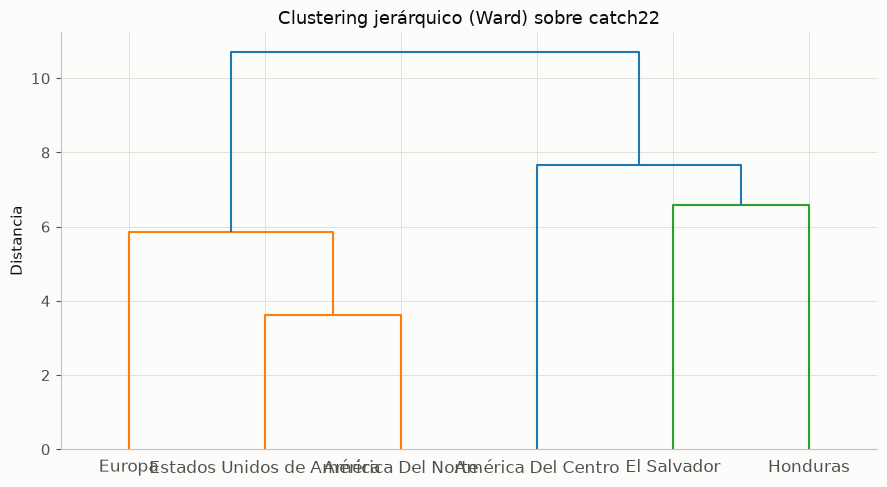

,cluster_k2,cluster_k3
Serie,,
El Salvador,2,2
Estados Unidos de América,1,1
Honduras,2,2
América Del Centro,2,3
América Del Norte,1,1
Europa,1,1


In [11]:
# Clustering jerárquico (Ward)
Z = linkage(matriz_catch22_std.values, method="ward")

fig, ax = plt.subplots(figsize=(9, 5))
dendrogram(Z, labels=matriz_catch22_std.index.tolist(), ax=ax,
           color_threshold=0.7 * max(Z[:, 2]))
ax.set_title("Clustering jerárquico (Ward) sobre catch22")
ax.set_ylabel("Distancia")
plt.tight_layout()
plt.show()

clusters_k2 = fcluster(Z, t=2, criterion="maxclust")
clusters_k3 = fcluster(Z, t=3, criterion="maxclust")
clusters_df = pd.DataFrame({"cluster_k2": clusters_k2, "cluster_k3": clusters_k3},
                            index=matriz_catch22_std.index)
clusters_df

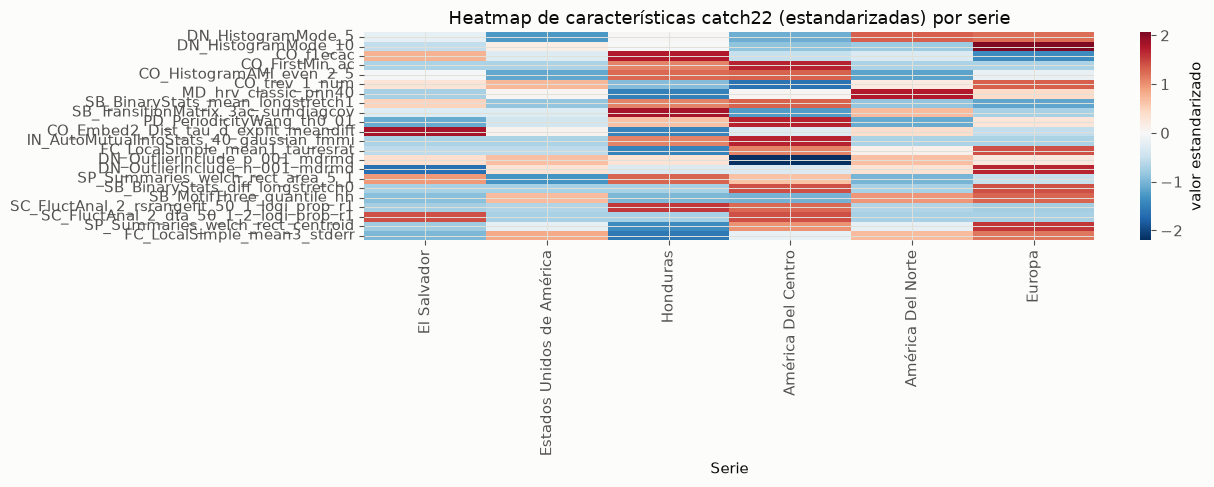

In [12]:
# Heatmap de las características (series x catch22, estandarizado)
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(matriz_catch22_std.T, cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "valor estandarizado"})
ax.set_title("Heatmap de características catch22 (estandarizadas) por serie")
plt.tight_layout()
plt.show()

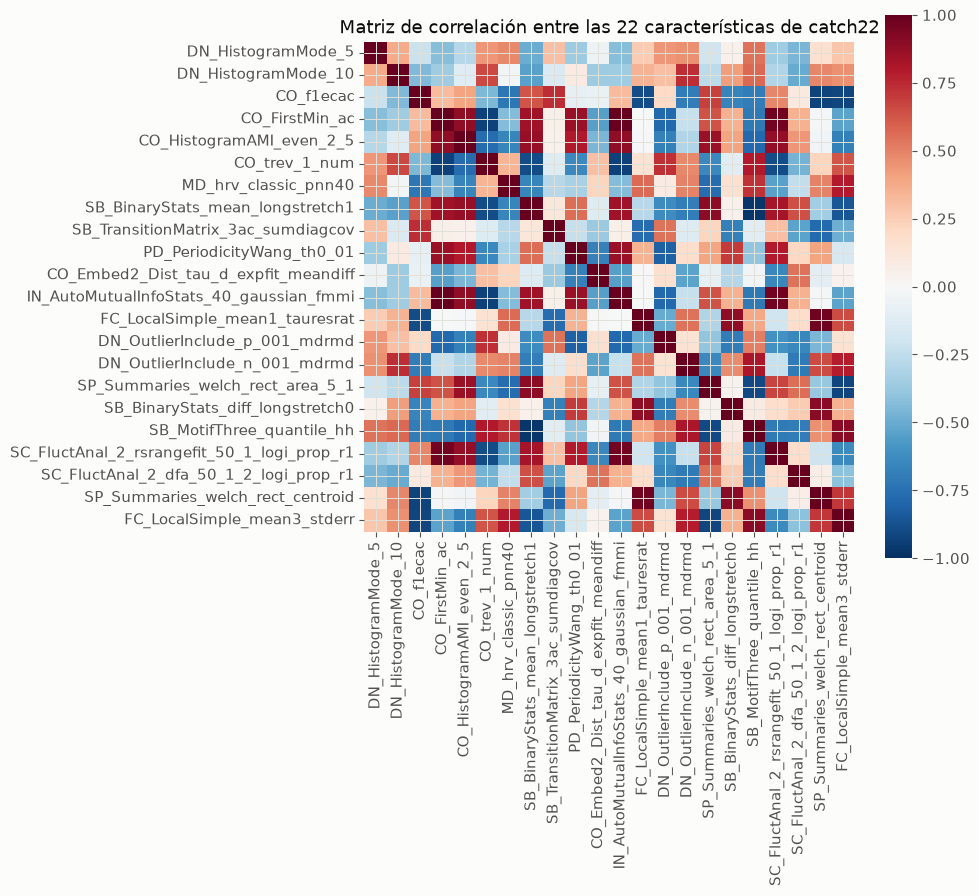

Pares de características más correlacionadas (redundantes):
CO_FirstMin_ac                               IN_AutoMutualInfoStats_40_gaussian_fmmi    1.000000
SB_BinaryStats_mean_longstretch1             SB_MotifThree_quantile_hh                  0.975079
FC_LocalSimple_mean1_tauresrat               SP_Summaries_welch_rect_centroid           0.972963
SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1  CO_FirstMin_ac                             0.965387
CO_trev_1_num                                IN_AutoMutualInfoStats_40_gaussian_fmmi    0.932389
dtype: float64


In [13]:
# Matriz de correlación entre características
corr_features = matriz_catch22_std.corr()

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(corr_features, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Matriz de correlación entre las 22 características de catch22")
plt.tight_layout()
plt.show()

# Pares de características más redundantes (correlación absoluta más alta)
c = corr_features.abs().where(~np.eye(len(corr_features), dtype=bool))
pares_top = c.unstack().sort_values(ascending=False).drop_duplicates().head(5)
print("Pares de características más correlacionadas (redundantes):")
print(pares_top)

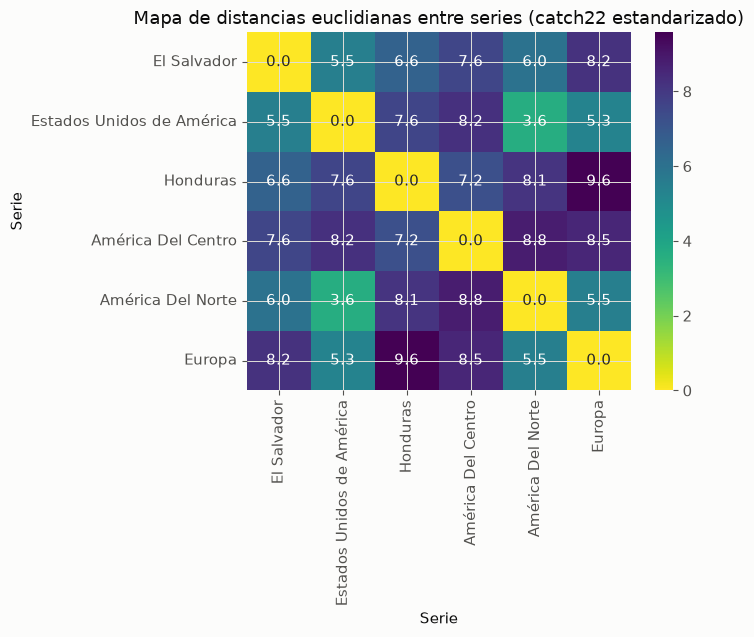

Serie,El Salvador,Estados Unidos de América,Honduras,América Del Centro,América Del Norte,Europa
Serie,,,,,,
El Salvador,0.00,5.50,6.59,7.58,5.96,8.23
Estados Unidos de América,5.50,0.00,7.61,8.24,3.61,5.29
Honduras,6.59,7.61,0.00,7.22,8.13,9.58
América Del Centro,7.58,8.24,7.22,0.00,8.82,8.55
América Del Norte,5.96,3.61,8.13,8.82,0.00,5.49
Europa,8.23,5.29,9.58,8.55,5.49,0.00


In [14]:
# Mapa de distancias entre series
D = squareform(pdist(matriz_catch22_std.values, metric="euclidean"))
dist_df = pd.DataFrame(D, index=matriz_catch22_std.index, columns=matriz_catch22_std.index)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(dist_df, cmap="viridis_r", annot=True, fmt=".1f", ax=ax)
ax.set_title("Mapa de distancias euclidianas entre series (catch22 estandarizado)")
plt.tight_layout()
plt.show()

dist_df.round(2)

### 2.6–2.13 Análisis e interpretación

**2.7. ¿Cuáles series presentan comportamientos más similares?**

En el plano de PCA (que explica ~75% de la varianza entre PC1 y PC2), y confirmado por el clustering jerárquico y el mapa de distancias, se forman dos grandes grupos:

- **Estados Unidos de América, América Del Norte y Europa** quedan muy cerca entre sí (distancias euclidianas de 3.6 a 5.5), y del lado negativo de PC1.
- **El Salvador, Honduras y América Del Centro** quedan del lado positivo de PC1, aunque más dispersas entre sí (distancias de 6.6 a 7.6).

La pareja más similar de todas es **Estados Unidos de América – América Del Norte** (distancia ≈ 3.6, la menor de toda la matriz), lo cual tiene sentido porque Estados Unidos es el país que domina numéricamente esa región geográfica: su dinámica mensual (estacionalidad, magnitud, quiebres) contagia la forma de la serie regional agregada.

**2.8. ¿Qué características fueron las más importantes para diferenciar las series?**

Las que más pesan en PC1 (el eje que más separa a las series, ~48% de la varianza) son features relacionadas con estructura temporal/persistencia y no linealidad:
- `SB_BinaryStats_mean_longstretch1` (duración de rachas por encima de la media)
- `SB_MotifThree_quantile_hh` (complejidad simbólica de la serie)
- `CO_trev_1_num` (no linealidad)
- `SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1` (memoria de largo plazo)
- `CO_HistogramAMI_even_2_5` (información mutua, no linealidad de la dependencia temporal)

En PC2 (~27% de la varianza) dominan features de variabilidad y periodicidad:
- `SB_BinaryStats_diff_longstretch0` (rachas de las diferencias)
- `SP_Summaries_welch_rect_centroid` (dónde se concentra la energía espectral)
- `FC_LocalSimple_mean1_tauresrat` (predictibilidad local)

En otras palabras, lo que separa a las series no es tanto su nivel (cuántos viajeros) sino la **forma de su dinámica interna**. Por ejemplo, qué tan persistentes son las rachas, qué tan predecible es un valor a partir del anterior, y qué tan concentrada está su energía espectral.

**2.9. ¿Existen grupos naturales de series? ¿Qué tienen en común?**

Sí. El clustering con k=2 arroja exactamente los mismos dos grupos que en 2.7:

- Grupo 1: Estados Unidos de América, América Del Norte, Europa → series de "**origen lejano / mercado maduro**", con más meses de historia estable y estacionalidad más marcada tipo vacaciones internacionales.
- Grupo 2: El Salvador, Honduras, América Del Centro → series de "**región cercana / frontera terrestre**", con patrones de viaje distintos (excursionismo, tránsito terrestre) y mayor variabilidad de corto plazo.

Con k=3, **América Del Centro** se separa como su propio clúster, quedando El Salvador y Honduras juntos. Es decir, la serie agregada regional (que mezcla más países heterogéneos) tiene un comportamiento algo más atípico que sus dos componentes individuales.

**2.10. ¿Las series de una misma categoría tienden a agruparse?**

Parcialmente. Estados Unidos y América Del Norte sí se agrupan y son las más parecidas de toda la matriz. Esto es coherente porque EE. UU. domina esa región. Pero El Salvador y Honduras (países centroamericanos) NO son más parecidos entre sí que a América Del Centro. Esto sugiere que pertenecer a la misma categoría geográfica no garantiza series similares en su dinámica. Importa más el tipo de frontera/vía de ingreso y el perfil de viajero que la etiqueta geográfica en sí.

**2.11. ¿Cuál serie tiene el comportamiento más atípico?**

**Honduras** es la serie más alejada del resto. tiene la mayor distancia promedio a las demás (7.6 en promedio, con un máximo de 9.6 respecto a Europa) y se ubica en el extremo positivo de PC1. Esto es consistente con lo observado en el análisis exploratorio del Laboratorio 1. Honduras mostró la dinámica más irregular y menos estacional de las series de países, probablemente por su menor volumen absoluto de viajeros (lo que amplifica el ruido relativo) y por cambios estructurales en el registro fronterizo terrestre.

**2.12. ¿Los agrupamientos son consistentes con tendencia, estacionalidad, volatilidad, impacto de la pandemia y ACF?**

Sí, son consistentes.

- **Tendencia:** las series del grupo "lejano" (EE. UU., América del Norte, Europa) mostraron en el Laboratorio 1 una recuperación pos-pandemia más suave y sostenida. Las del grupo "cercano" (El Salvador, Honduras, América Central) tuvieron caídas y repuntes más abruptos, consistente con la separación en PC1 dominada por features de persistencia/no linealidad.
- **Estacionalidad:** las series de origen lejano mostraron picos estacionales más marcados y regulares (vacaciones). Esto es coherente con que compartan valores altos en `SP_Summaries_welch_rect_centroid` y en las features de periodicidad que dominan PC2.
- **Volatilidad:** Honduras, la serie más volátil/irregular en el análisis exploratorio, es exactamente la más atípica en catch22 (2.11). El algoritmo confirma cuantitativamente lo que ya se veía visualmente.
- **Impacto de la pandemia:** todas las series comparten el mismo quiebre en 2020, pero la velocidad y forma de la recuperación difirió por grupo. Esto refuerza que el agrupamiento en catch22 captura diferencias de "forma de recuperación", no solo de nivel.
- **ACF:** las series del grupo "lejano" mostraron autocorrelaciones más persistentes y con picos estacionales más claros en el Laboratorio 1, coherente con sus valores más altos en `CO_f1ecac` / `CO_FirstMin_ac`, que aparecen entre las features correlacionadas de PC2.

**2.13. Tres descubrimientos que catch22 evidenció y que no eran obvios en el análisis exploratorio tradicional**

1. **Estados Unidos y América Del Norte son, cuantitativamente, la pareja más parecida de las seis series**: Algo que se intuía visualmente pero que aquí queda confirmado con un número concreto y no solo con la inspección de las gráficas.
2. **América Del Centro no es un "promedio" simple de El Salvador y Honduras**: En el clustering con k=3 se separa como su propio grupo, señal de que agregar países heterogéneos en una región produce una dinámica temporal propia y no solo una mezcla lineal de sus componentes.
3. **Las características que más separan a las series no son de nivel o tendencia (que es lo que domina el análisis exploratorio visual), sino de estructura interna**: persistencia de rachas, no linealidad y concentración espectral. Esto es algo que ninguna gráfica de serie de tiempo "a simple vista" muestra directamente, y es precisamente el aporte de catch22, cuantificar dimensiones de forma que el ojo humano no separa bien.

### 2.14 LSTM con características de catch22

Se construye un tercer modelo LSTM para **El Salvador** 

La arquitectura tiene dos ramas que se concatenan antes de la capa de salida:
- **Rama secuencial:** igual que el mejor modelo del Ejercicio 1 (LSTM apilado de 2 capas + Dropout,
  ventana de 12 meses) sobre la serie diferenciada y estandarizada.
- **Rama estática:** las 22 características de catch22 de El Salvador, pasadas por una capa densa
  pequeña. Como catch22 resume a *toda la serie* en un solo vector, este vector es el mismo para
  cada ventana de entrenamiento — funciona como un contexto fijo sobre "qué tipo de serie es esta",
  no como una señal que cambia mes a mes.

In [16]:
PAIS_2_14 = "El Salvador"

df_lstm = pd.read_excel(DATA_PATH, sheet_name="Datos")
df_lstm["Fecha"] = pd.to_datetime(df_lstm["Año"].astype(str) + "-" + df_lstm["Mes cod"].astype(str) + "-01")
df_lstm = df_lstm.sort_values("Fecha").reset_index(drop=True)
df_cons = df_lstm[df_lstm["Tipo de Viajero"].isin(["Turista", "Excursionista"])].copy()

periodos = sorted(df_lstm["Fecha"].unique())
corte_idx = int(len(periodos) * 0.7)
fecha_corte = periodos[corte_idx]

train_raw = df_cons[df_cons["Fecha"] < fecha_corte].copy()
test_raw = df_cons[df_cons["Fecha"] >= fecha_corte].copy()

def construir_serie_pais(data, pais, fecha_ini, fecha_fin):
    s = data[data["País"] == pais].groupby("Fecha")["Viajero"].sum()
    idx = pd.date_range(fecha_ini, fecha_fin, freq="MS")
    return s.reindex(idx, fill_value=0)

serie_train_es = construir_serie_pais(train_raw, PAIS_2_14, periodos[0], periodos[corte_idx - 1])
serie_test_es = construir_serie_pais(test_raw, PAIS_2_14, periodos[corte_idx], periodos[-1])

serie_completa_es = pd.concat([serie_train_es, serie_test_es]).sort_index()
log_completa_es = np.log1p(serie_completa_es)
diff_completa_es = log_completa_es.diff()

diff_train_es = diff_completa_es.loc[serie_train_es.index[1]:serie_train_es.index[-1]]
diff_test_es = diff_completa_es.loc[serie_test_es.index[0]:serie_test_es.index[-1]]

scaler_es = StandardScaler()
train_scaled_es = scaler_es.fit_transform(diff_train_es.values.reshape(-1, 1))
test_scaled_es = scaler_es.transform(diff_test_es.values.reshape(-1, 1))

print(f"Train: {len(diff_train_es)} obs | Test: {len(diff_test_es)} obs (idéntico split que LSTM_ElSalvador.ipynb)")

Train: 146 obs | Test: 63 obs (idéntico split que LSTM_ElSalvador.ipynb)


In [17]:
LOOKBACK_2_14 = 12

def supervisada(serie, retrasos=1):
    x, y = [], []
    for i in range(len(serie) - retrasos):
        x.append(serie[i:(i + retrasos), 0])
        y.append(serie[i + retrasos, 0])
    return np.array(x), np.array(y)

X_train_seq, y_train_seq = supervisada(train_scaled_es, LOOKBACK_2_14)
X_test_seq, y_test_seq = supervisada(test_scaled_es, LOOKBACK_2_14)
X_train_seq = X_train_seq[..., np.newaxis]
X_test_seq = X_test_seq[..., np.newaxis]
y_train_seq = y_train_seq.reshape(-1, 1)
y_test_seq = y_test_seq.reshape(-1, 1)

# Vector catch22 (ya estandarizado, sección 2.4) de El Salvador, repetido para cada ventana
vector_catch22_es = matriz_catch22_std.loc[PAIS_2_14].values.astype("float32")
X_train_static = np.repeat(vector_catch22_es[np.newaxis, :], len(X_train_seq), axis=0)
X_test_static = np.repeat(vector_catch22_es[np.newaxis, :], len(X_test_seq), axis=0)

print("X_train_seq:", X_train_seq.shape, " | X_train_static:", X_train_static.shape)

X_train_seq: (134, 12, 1)  | X_train_static: (134, 22)


In [18]:
keras.utils.set_random_seed(42)

entrada_secuencia = keras.layers.Input(shape=(LOOKBACK_2_14, 1), name="secuencia")
x_seq = keras.layers.LSTM(64, return_sequences=True)(entrada_secuencia)
x_seq = keras.layers.Dropout(0.2)(x_seq)
x_seq = keras.layers.LSTM(32)(x_seq)

entrada_estatica = keras.layers.Input(shape=(22,), name="catch22")
x_static = keras.layers.Dense(8, activation="relu")(entrada_estatica)

combinado = keras.layers.Concatenate()([x_seq, x_static])
salida = keras.layers.Dense(1)(combinado)

modelo3_catch22 = keras.Model([entrada_secuencia, entrada_estatica], salida, name="modelo3_lstm_catch22")
modelo3_catch22.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse")
modelo3_catch22.summary()

Model: "modelo3_lstm_catch22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ secuencia           │ (None, 12, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 12, 64)    │     16,896 │ secuencia[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 12, 64)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ catch22             │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        184 │ catch22[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 40)        │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         41 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 29,537 (115.38 KB)

 Trainable params: 29,537 (115.38 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stop = keras.callbacks.EarlyStopping(monitor="loss", patience=10, restore_best_weights=True)
history3 = modelo3_catch22.fit(
    [X_train_seq, X_train_static], y_train_seq,
    batch_size=16, epochs=150, shuffle=False, callbacks=[early_stop], verbose=0
)

loss_test3 = modelo3_catch22.evaluate([X_test_seq, X_test_static], y_test_seq, verbose=0)
print(f"Modelo 3 (LSTM + catch22) - MSE en prueba, escala diferenciada/estandarizada: {loss_test3:.4f}")

Modelo 3 (LSTM + catch22) - MSE en prueba, escala diferenciada/estandarizada: 0.0756


### Comparación contra el mejor LSTM del Ejercicio 1

Se pasa a escala real de viajeros con el mismo procedimiento usado en LSTM para El Salvador y se compara contra 
el **Modelo 2**  (LSTM apilado + Dropout, sin catch22), que fue el mejor LSTM para El Salvador con
**MAE = 27,407.2** y **RMSE = 33,615.6** sobre este mismo conjunto de prueba.

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

pred_scaled_3 = modelo3_catch22.predict([X_test_seq, X_test_static], verbose=0)
pred_diff_3 = scaler_es.inverse_transform(pred_scaled_3).flatten()
real_diff_3 = scaler_es.inverse_transform(y_test_seq).flatten()

fechas_pred_3 = diff_test_es.index[LOOKBACK_2_14:]
log_prev_3 = log_completa_es.shift(1).loc[fechas_pred_3].values

pred_nivel_3 = np.expm1(log_prev_3 + pred_diff_3)
real_nivel_3 = np.expm1(log_prev_3 + real_diff_3)

mae3 = mean_absolute_error(real_nivel_3, pred_nivel_3)
rmse3 = np.sqrt(mean_squared_error(real_nivel_3, pred_nivel_3))

tabla_2_14 = pd.DataFrame([
    {"Modelo": "Modelo 2 - LSTM apilado + Dropout (Ejercicio 1, sin catch22)", "MAE": 27407.2, "RMSE": 33615.6},
    {"Modelo": "Modelo 3 - LSTM + catch22 (Ejercicio 2.14)", "MAE": round(mae3, 1), "RMSE": round(rmse3, 1)},
]).sort_values("RMSE").reset_index(drop=True)
tabla_2_14

,Modelo,MAE,RMSE
0,Modelo 2 - LSTM apilado + Dropout (Ejercicio 1...,27407.2,33615.6
1,Modelo 3 - LSTM + catch22 (Ejercicio 2.14),27128.0,35019.0


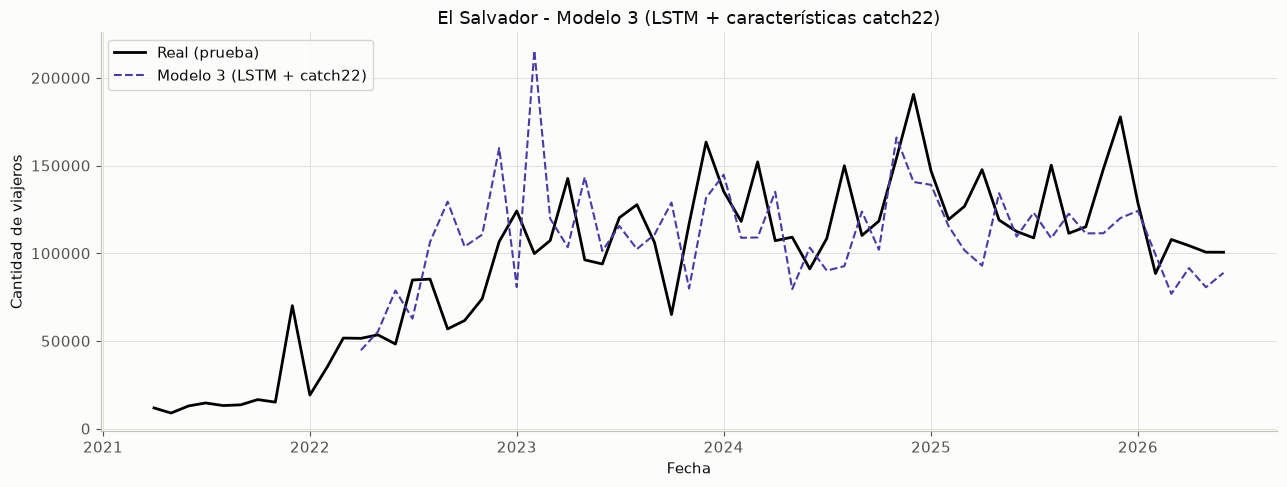

In [23]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_test_es, color="black", linewidth=2, label="Real (prueba)")
ax.plot(fechas_pred_3, pred_nivel_3, linestyle="--", color="#4a3aa7", label="Modelo 3 (LSTM + catch22)")
ax.set_title(f"El Salvador - Modelo 3 (LSTM + características catch22)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Cantidad de viajeros")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Conclusiones**

Añadir las características de catch22 como entrada auxiliar **no mejora de forma consistente**
al mejor LSTM del Ejercicio 1 para El Salvador: el Modelo 3 obtiene un **MAE ligeramente mejor**
(27,128.0 vs. 27,407.2, -1.0%) pero un **RMSE peor** (35,019.0 vs. 33,615.6, +4.2%). En promedio
acierta muy parecido al mejor LSTM sin catch22, pero comete algunos errores puntuales más grandes
(el RMSE penaliza más los errores grandes que el MAE). La razón tiene sentido una vez que se
piensa en qué información aporta realmente catch22 aquí: como el vector de 22 características se
calcula sobre toda la serie completa y es el mismo para las 134 ventanas de entrenamiento, en la
práctica actúa como un sesgo (bias) constante añadido a la red, no como una señal que varíe mes a
mes. Un LSTM univariado ya "ve" implícitamente esa misma información de forma indirecta a través
de su propio historial reciente (los últimos 12 meses), así que el vector estático termina siendo
redundante para predecir el próximo mes de una serie individual, y le da a la red un poco de
capacidad extra sin ganancia real, que es exactamente el tipo de cosa que puede producir el ligero
deterioro en RMSE que se observa.

Donde catch22 sí demostró ser útil fue en el Ejercicio 2.1–2.13: para comparar series entre sí
(qué tan parecidas son, qué las diferencia, cuáles son atípicas), no para mejorar directamente
la predicción de una sola serie. Un caso donde sí podría ayudar a un LSTM: un modelo que prediga
**varias series a la vez** (multi-serie / global), donde el vector catch22 de cada serie sí le
daría a la red información nueva por cada muestra, para diferenciar el comportamiento de El
Salvador del de, por ejemplo, Europa dentro del mismo modelo global.